# X-Ray Luggage Scanner — Model 1 Training Pipeline

**AI/ML-Based Dual-Model Property-Based Object Detection System**

This notebook implements the complete Phase 3 pipeline:

| Section | Purpose |
|---|---|
| §1 Environment | Install dependencies, mount Drive, verify GPU |
| §2 Imports & Config | Load all modules and `default.yaml` |
| §3 Dataset Organization | Organize raw SIXray/OPIXray into standardized format |
| §4 Property Annotation | Compute 11-property vectors for every detected object |
| §5 Stratified Splits | Create train/val/test splits with class balancing |
| §6 Model Init | Build PropertyYOLO (YOLOv8m + property head + material branch) |
| §7 Training | Stage 1: detection (SGD, 100 ep) → Stage 2: property regression (Adam, 50 ep) |
| §8 Evaluation & Save | Compute metrics on test set, save checkpoint to Drive |

---

### Prerequisites

1. **GPU Runtime:** Go to **Runtime → Change runtime type → GPU (T4)**
2. **Dataset:** Upload your X-ray dataset (SIXray or OPIXray) to Google Drive at:
   ```
   /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/raw/sixray/
   /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/raw/opixray/
   ```
3. **Expected format:** See the README for directory structure requirements.

### Dependencies

| Package | Min Version | Purpose |
|---|---|---|
| PyTorch | 2.0+ | Deep learning framework |
| Ultralytics | 8.0+ | YOLOv8 backbone |
| OpenCV | 4.8+ | Image preprocessing |
| Albumentations | 1.3+ | Data augmentation |
| Pandas | 2.0+ | Property annotations |
| scikit-learn | 1.3+ | Stratified splitting |

## §1 · Environment Setup

In [2]:
# ---- Mount Google Drive ----
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ---- Clone repository & install dependencies ----
import os, subprocess, sys

REPO_DIR = "/content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security"
DRIVE_ROOT = REPO_DIR

# Validate directory exists
if not os.path.isdir(REPO_DIR):
    print("\u2716 Repository not found at:", REPO_DIR)
    print("  Please upload the project to Google Drive at:")
    print("  /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/")
    raise FileNotFoundError(f"Repository not found: {REPO_DIR}")
print(f"\u2713 Repository found at: {REPO_DIR}")

os.chdir(REPO_DIR)

# Install dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
print("\u2713 Dependencies installed")

# Print version table
import torch, cv2, numpy, pandas, ultralytics
print(f"\n{'Package':<20} {'Version'}")
print("-" * 40)
for name, mod in [("Python", sys), ("PyTorch", torch), ("CUDA", None),
                   ("OpenCV", cv2), ("NumPy", numpy), ("Pandas", pandas),
                   ("Ultralytics", ultralytics)]:
    if name == "Python":
        ver = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
    elif name == "CUDA":
        ver = torch.version.cuda or "N/A"
    else:
        ver = getattr(mod, "__version__", "?")
    print(f"{name:<20} {ver}")

# GPU check
assert torch.cuda.is_available(), (
    "\u2716 No GPU detected. Go to Runtime \u2192 Change runtime type \u2192 GPU (T4)"
)
gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\n\u2713 GPU: {gpu_name} ({gpu_mem:.1f} GB)")

✓ Repository found at: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security
✓ Dependencies installed
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Package              Version
----------------------------------------
Python               3.12.12
PyTorch              2.10.0+cu128
CUDA                 12.8
OpenCV               4.13.0
NumPy                2.0.2
Pandas               2.2.2
Ultralytics          8.4.21

✓ GPU: Tesla T4 (15.6 GB)


## §2 · Imports & Configuration

All imports are consolidated here. Configuration is loaded from
`configs/default.yaml` — training hyperparameters, class names,
property schema, and paths are all defined there.

In [ ]:
import sys, os, time, glob, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, ".")

# --- Project modules ---
from src.utils.config import load_config
from src.dataset.download import (
    setup_data_directories, list_available_datasets,
    validate_dataset, organize_sixray, organize_opixray,
)
from src.dataset.property_annotator import (
    PropertyAnnotator, batch_annotate, PROPERTY_NAMES,
)
from src.dataset.splits import create_splits, create_yolo_data_yaml
from src.dataset.xray_dataset import XRayDataset, collate_fn
from src.model1.architecture import PropertyYOLO
from src.model1.loss import MultiTaskLoss
from src.model1.train import Trainer
from src.model1.evaluate import Model1Evaluator
from src.utils.visualization import (
    plot_training_curves, plot_confusion_matrix,
    plot_property_distributions,
)

# --- Load configuration ---
config = load_config("configs/default.yaml")
device = "cuda"

# --- Resolve paths ---
DATA_ROOT = os.path.join(DRIVE_ROOT, "data")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
RESULTS_DIR = os.path.join(DRIVE_ROOT, "results")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\u2713 Config: {config['project']['name']} v{config['project']['version']}")
print(f"  Backbone:     {config['model1']['backbone']}")
print(f"  Classes:      {config['dataset']['threat_classes']}")
print(f"  Properties:   {config['property_schema']['num_properties']}")
print(f"  Image size:   {config['dataset']['image_size']}")
print(f"  Stage 1:      {config['model1']['stage1']['epochs']} epochs (SGD)")
print(f"  Stage 2:      {config['model1']['stage2']['epochs']} epochs (Adam)")
print(f"\n\u2713 All imports successful")

✓ Config: xray-object-detection v0.1.0
  Backbone:     yolov8m
  Classes:      ['gun', 'knife', 'wrench', 'pliers', 'scissors']
  Properties:   11
  Image size:   640
  Stage 1:      100 epochs (SGD)
  Stage 2:      50 epochs (Adam)

✓ All imports successful


## §3 · Dataset Organization

Organizes raw SIXray/OPIXray images and YOLO-format labels into a
standardized `data/processed/` directory:

```
data/processed/
  images/   \u2190 all .jpg/.png images
  labels/   \u2190 matching .txt files (YOLO: class cx cy w h)
```

> **Action required:** Before running this cell, upload your dataset
> to `data/raw/sixray/` or `data/raw/opixray/` on Google Drive.

In [ ]:
# ---- Create directory structure ----
dirs = setup_data_directories(DATA_ROOT)
list_available_datasets()

# ---- Organize raw datasets ----
raw_dir = os.path.join(DATA_ROOT, "raw")
processed_dir = os.path.join(DATA_ROOT, "processed")
img_dir = os.path.join(processed_dir, "images")
label_dir = os.path.join(processed_dir, "labels")

# Organize SIXray if present (checking for Roboflow structure first)
sixray_dir = os.path.join(raw_dir, "sixray")
if os.path.isdir(sixray_dir) and os.listdir(sixray_dir):
    print("\n\U0001f4e6 Organizing SIXray dataset...")
    # Check if it's a Roboflow export (has train/valid/test)
    is_roboflow = any(os.path.isdir(os.path.join(sixray_dir, split)) for split in ["train", "valid", "test"])

    if is_roboflow:
        print("  Found Roboflow pre-split format. Flattening into processed directory...")
        import shutil
        for split in ["train", "valid", "test", "val"]:
            split_dir = os.path.join(sixray_dir, split)
            if not os.path.isdir(split_dir): continue

            # Copy images
            split_img_dir = os.path.join(split_dir, "images")
            if os.path.isdir(split_img_dir):
                for f in os.listdir(split_img_dir):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        shutil.copy2(os.path.join(split_img_dir, f), os.path.join(img_dir, f))

            # Copy labels
            split_label_dir = os.path.join(split_dir, "labels")
            if os.path.isdir(split_label_dir):
                for f in os.listdir(split_label_dir):
                    if f.endswith('.txt'):
                        shutil.copy2(os.path.join(split_label_dir, f), os.path.join(label_dir, f))
    else:
        organize_sixray(sixray_dir, processed_dir)

# Organize OPIXray if present
opixray_dir = os.path.join(raw_dir, "opixray")
if os.path.isdir(opixray_dir) and os.listdir(opixray_dir):
    print("\n\U0001f4e6 Organizing OPIXray dataset...")
    # Check if it's a Roboflow export
    is_roboflow = any(os.path.isdir(os.path.join(opixray_dir, split)) for split in ["train", "valid", "test"])
    if is_roboflow:
        print("  Found Roboflow pre-split format. Flattening into processed directory...")
        import shutil
        for split in ["train", "valid", "test", "val"]:
            split_dir = os.path.join(opixray_dir, split)
            if not os.path.isdir(split_dir): continue

            split_img_dir = os.path.join(split_dir, "images")
            if os.path.isdir(split_img_dir):
                for f in os.listdir(split_img_dir):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        shutil.copy2(os.path.join(split_img_dir, f), os.path.join(img_dir, f))

            split_label_dir = os.path.join(split_dir, "labels")
            if os.path.isdir(split_label_dir):
                for f in os.listdir(split_label_dir):
                    if f.endswith('.txt'):
                        shutil.copy2(os.path.join(split_label_dir, f), os.path.join(label_dir, f))
    else:
        organize_opixray(opixray_dir, processed_dir)

# ---- Validate ----
stats = validate_dataset(processed_dir)

assert stats["total_images"] > 0, (
    "\u2716 No images found in data/processed/images/. "
    "Upload your dataset to data/raw/sixray/ or data/raw/opixray/ on Drive first."
)
print(f"\n\u2713 Dataset ready: {stats['total_images']} images, {stats['total_labels']} labels")

  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/raw
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/raw/sixray
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/raw/opixray
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/processed
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/processed/images
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/processed/labels
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/annotations
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/annotations/properties
  ✓ Created: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/augmented
Available X-Ray Security Datasets

📦 SIXRAY
   SIXray Dataset (Miao et al.

## §4 · Property Annotation

Computes the 11-dimensional property vector for each bounding-box
object using OpenCV-based feature extraction:

| # | Property | Type | Method |
|---|---|---|---|
| 0 | Edge sharpness | float [0,1] | Canny edge density |
| 1 | Length-to-width ratio | float [0,10] | Bbox aspect ratio |
| 2 | Symmetry score | float [0,1] | Horizontal pixel comparison |
| 3 | Curvature index | float [0,1] | Contour vs convex hull |
| 4 | Approximate volume | float [0,1] | Area × opacity depth |
| 5 | Material category | int {0–3} | Intensity distribution |
| 6 | Avg absorption | float [0,1] | Mean pixel value |
| 7 | Material homogeneity | float [0,1] | Inverted std dev |
| 8 | Density level | float [0,1] | Inverted mean intensity |
| 9 | Sharp edge count | int [0,20] | Shi-Tomasi corners |
| 10 | Occlusion score | float [0,1] | Bbox overlap fraction |

🔬 Computing properties for 8312 images...


Computing properties: 100%|██████████| 8312/8312 [03:01<00:00, 45.71it/s]


✓ Saved 15668 property annotations to /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/annotations/properties.csv

✓ Annotated 15668 objects across 8312 images

Property statistics:
       edge_sharpness  length_to_width_ratio  symmetry_score  curvature_index  \
count       15668.000              15668.000       15668.000          15668.0   
mean            0.192                  2.011           0.765              0.0   
std             0.056                  1.158           0.061              0.0   
min             0.012                  1.000           0.442              0.0   
25%             0.152                  1.289           0.728              0.0   
50%             0.191                  1.650           0.771              0.0   
75%             0.230                  2.320           0.808              0.0   
max             0.386                 10.000           0.929              0.0   

       approximate_volume  material_category  avg_absorption

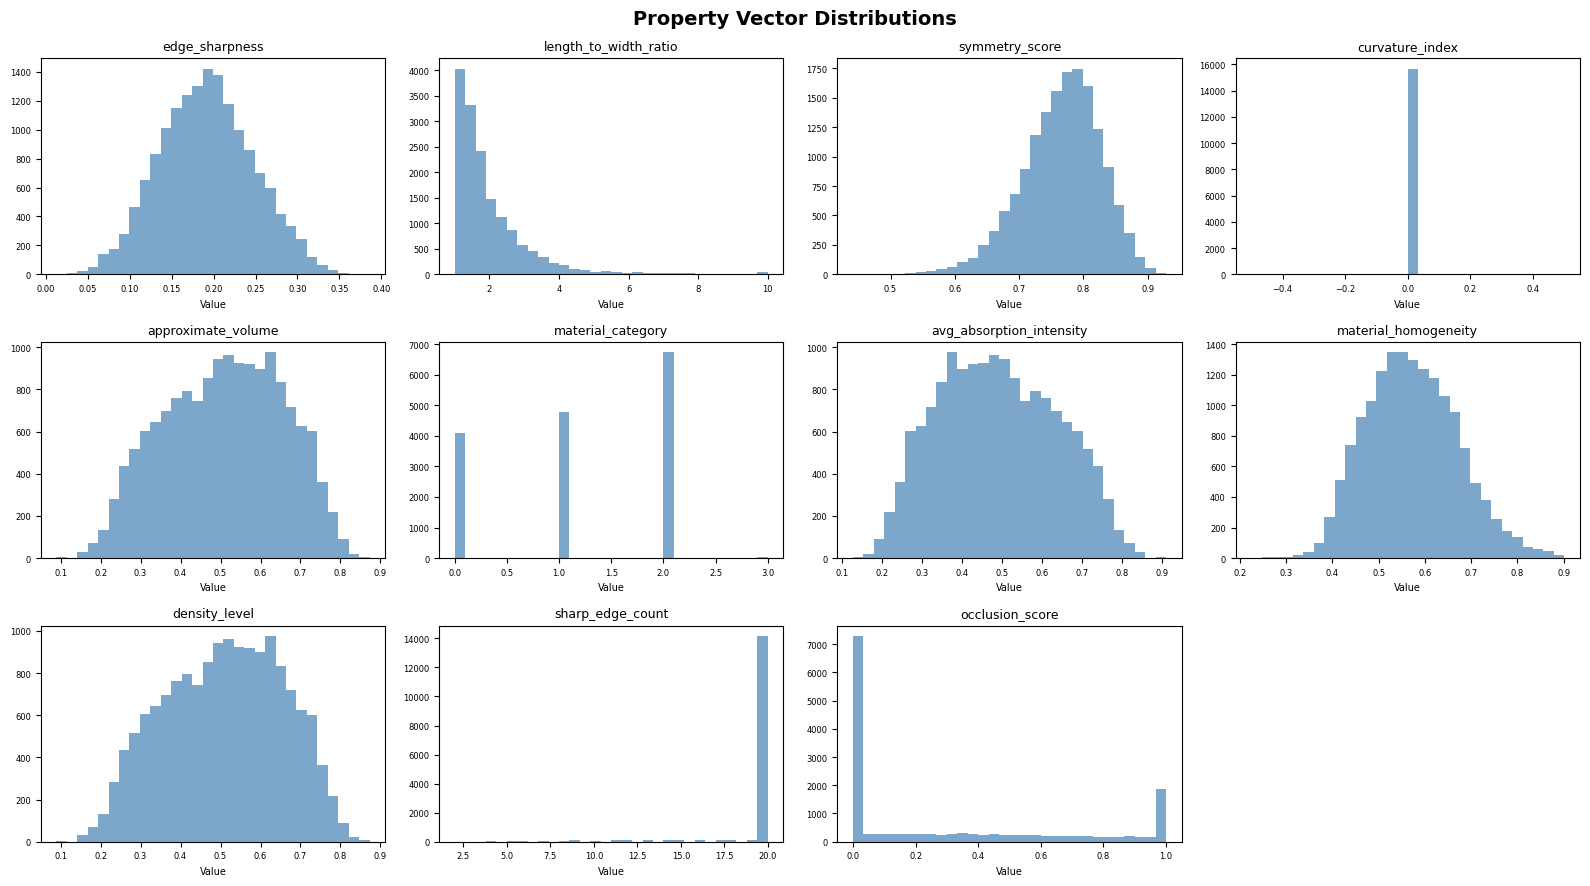

In [ ]:
# ---- Compute property annotations for all objects ----
annotator = PropertyAnnotator()

image_files = sorted(glob.glob(os.path.join(img_dir, "*.*")))
label_files = [
    os.path.join(
        label_dir,
        os.path.splitext(os.path.basename(f))[0] + ".txt",
    )
    for f in image_files
]

output_csv = os.path.join(DATA_ROOT, "annotations", "properties.csv")
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

print(f"\U0001f52c Computing properties for {len(image_files)} images...")
props_df = batch_annotate(image_files, label_files, output_csv, annotator)

assert len(props_df) > 0, (
    "\u2716 Property annotation produced 0 rows. "
    "Check that label files exist and contain valid YOLO annotations."
)

print(f"\n\u2713 Annotated {len(props_df)} objects across {len(image_files)} images")
print(f"\nProperty statistics:")
print(props_df[PROPERTY_NAMES].describe().round(3))

# ---- Visualize property distributions ----
prop_values = props_df[PROPERTY_NAMES].values.astype(np.float32)
plot_property_distributions(prop_values, PROPERTY_NAMES)
plt.savefig(os.path.join(RESULTS_DIR, "property_distributions.png"), dpi=150)
plt.show()

## §5 · Stratified Train / Val / Test Splits

Creates class-balanced splits (70/15/15) using the primary object
class in each image as the stratification key. This prevents data
leakage — no image appears in more than one split.

The YOLO `data.yaml` file is generated for Stage 1 detection training.

In [ ]:
# ---- Create stratified splits ----
split_dir = os.path.join(DATA_ROOT, "splits")
data_yaml = os.path.join(DATA_ROOT, "data.yaml")

train_ratio = config["dataset"]["train_ratio"]
val_ratio = config["dataset"]["val_ratio"]
test_ratio = config["dataset"]["test_ratio"]

train_files, val_files, test_files = create_splits(
    img_dir, label_dir, split_dir,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    seed=42,
    create_symlinks=True,
)

assert len(train_files) > 0, "\u2716 Train split is empty."
assert len(val_files) > 0, "\u2716 Validation split is empty."

# ---- Generate YOLO data.yaml ----
class_names = config["dataset"]["threat_classes"]
create_yolo_data_yaml(split_dir, class_names, data_yaml)

print(f"\n\u2713 Splits created: train={len(train_files)}, "
      f"val={len(val_files)}, test={len(test_files)}")
print(f"\u2713 data.yaml: {data_yaml}")

  ✓ Saved: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/splits/train.txt (5814 images)
  ✓ Saved: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/splits/val.txt (1245 images)
  ✓ Saved: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/splits/test.txt (1253 images)

📊 Dataset Split Statistics:
   Total images: 8312
   Train: 5814 (69.9%)
   Val:   1245 (15.0%)
   Test:  1253 (15.1%)

   Class distribution:
   Train: {2: 2011, 0: 1671, 4: 753, 3: 636, 1: 732, -1: 11}
   Val: {2: 431, 3: 136, 0: 358, 1: 157, 4: 161, -1: 2}
   Test: {0: 359, 3: 137, 4: 163, 1: 158, 2: 432, -1: 4}
  ✓ Created split directories in /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/splits
✓ Created YOLO data.yaml: /content/drive/MyDrive/Object-Detection-in-Luggage-Scanner-for-Security/data/data.yaml

✓ Splits created: train=5814, val=1245, test=1253
✓ data.yaml: /content/drive/MyDrive/Object-Dete

## §6 · Model Initialization

**PropertyYOLO** = YOLOv8m backbone + dual heads:

- **Detection head** (standard YOLO): bbox + objectness + class
- **Property head** (MLP 512 → 256 → 10): continuous property regression
- **Material branch** (Linear → 4): material classification

The first conv layer is modified from 3 → 4 input channels to accept
the preprocessed 4-channel X-ray tensor.

In [ ]:
# ---- Build PropertyYOLO model ----
model_cfg = config["model1"]

model = PropertyYOLO(
    model_size=model_cfg["backbone"],
    num_classes=len(class_names) + 1,
    num_properties=model_cfg["property_head"]["num_outputs"],
    input_channels=model_cfg["input_channels"],
    pretrained=model_cfg["pretrained"],
    property_head_dims=model_cfg["property_head"]["hidden_dims"],
    material_branch=model_cfg["material_branch"]["enabled"],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\u2713 PropertyYOLO initialized")
print(f"  Backbone:           {model_cfg['backbone']}")
print(f"  Input channels:     {model_cfg['input_channels']}")
print(f"  Detection classes:  {len(class_names) + 1}")
print(f"  Property outputs:   {model_cfg['property_head']['num_outputs']}")
print(f"  Material classes:   {model_cfg['material_branch'].get('num_classes', 4)}")
print(f"  Total params:       {total_params:,}")
print(f"  Trainable params:   {trainable_params:,}")

# ---- Validate forward pass ----
model.eval()
with torch.no_grad():
    test_input = torch.randn(1, 4, 640, 640)
    output = model.forward_properties(test_input)
    assert output["properties"].shape == (1, model_cfg["property_head"]["num_outputs"]), (
        f"\u2716 Property head output shape mismatch: {output['properties'].shape}"
    )
print(f"\n\u2713 Forward pass validated: output shape {output['properties'].shape}")
del test_input, output
torch.cuda.empty_cache()

Loading configuration...

Building PropertyYOLO model...


NameError: name 'PropertyYOLO' is not defined

## §7 · Two-Stage Training

### Stage 1 — Detection (backbone + detection head)

Uses Ultralytics' optimized training loop with SGD, cosine LR schedule,
and mosaic augmentation. The property head is frozen.

### Stage 2 — Property Regression (property head + material branch)

Custom training loop with Adam optimizer and CosineAnnealingLR.
The backbone is frozen. Uses multi-task loss with uncertainty weighting
(Kendall et al., 2018) to automatically balance detection, property
regression, and material classification losses.

In [ ]:
# ---- Set up DataLoaders for Stage 2 ----
property_csv = os.path.join(DATA_ROOT, "annotations", "properties.csv")

train_dataset = XRayDataset(
    image_dir=os.path.join(split_dir, "train", "images"),
    label_dir=os.path.join(split_dir, "train", "labels"),
    property_csv=property_csv,
    image_size=config["dataset"]["image_size"],
)
val_dataset = XRayDataset(
    image_dir=os.path.join(split_dir, "val", "images"),
    label_dir=os.path.join(split_dir, "val", "labels"),
    property_csv=property_csv,
    image_size=config["dataset"]["image_size"],
)

batch_size = model_cfg["stage2"]["batch_size"]

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
)

print(f"\u2713 DataLoaders ready")
print(f"  Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"  Val:   {len(val_dataset)} images, {len(val_loader)} batches")
print(f"  Batch: {batch_size}")

In [ ]:
# ---- Initialize Trainer ----
config["data_yaml_path"] = data_yaml

trainer = Trainer(
    config=config,
    model=model,
    device=device,
    checkpoint_dir=CHECKPOINT_DIR,
)

# ==============================================================
# STAGE 1: Detection Training
# ==============================================================
print("\nStarting Stage 1: Detection Training...")
stage1_results = trainer.train_stage1(
    train_loader=train_loader,
    val_loader=val_loader,
)

# ==============================================================
# STAGE 2: Property Regression Training
# ==============================================================
print("\nStarting Stage 2: Property Regression Training...")
trainer.train_stage2(
    train_loader=train_loader,
    val_loader=val_loader,
)

# ---- Plot training curves ----
if trainer.history["train_loss"]:
    plot_training_curves(
        train_losses=trainer.history["train_loss"],
        val_losses=trainer.history.get("val_loss"),
    )
    plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150)
    plt.show()

print("\n\u2713 Both training stages complete")

## §8 · Evaluation & Save Checkpoint

Evaluates the trained model on the held-out **test split**:

- **Property regression:** per-property MAE and RMSE
- **Material classification:** accuracy, F1-score, confusion matrix
- **Consistency:** intra-class property vector cosine similarity

The final checkpoint is saved to Google Drive for persistence.

In [ ]:
# ---- Evaluate on test set ----
test_dataset = XRayDataset(
    image_dir=os.path.join(split_dir, "test", "images"),
    label_dir=os.path.join(split_dir, "test", "labels"),
    property_csv=property_csv,
    image_size=config["dataset"]["image_size"],
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
)
print(f"\u2713 Test set: {len(test_dataset)} images")

# ---- Run evaluation ----
evaluator = Model1Evaluator(
    property_names=PROPERTY_NAMES[:10],
    material_names=["organic", "metallic", "mixed", "opaque"],
)

model.eval()
model = model.to(device)

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        gt_props_list = batch["properties"]
        gt_labels_list = batch["labels"]

        # Forward pass
        output = model.forward_properties(images)
        pred_props = output["properties"].cpu().numpy()

        # Collect ground truth
        gt_props = torch.cat([p for p in gt_props_list if p.numel() > 0], dim=0)
        if gt_props.numel() == 0:
            continue

        gt_props_np = gt_props.numpy()[:, :10]  # First 10 continuous properties

        # Material predictions
        pred_materials = None
        gt_materials = None
        if "material_logits" in output:
            pred_materials = output["material_logits"].argmax(dim=1).cpu().numpy()
            gt_materials = gt_props.numpy()[:, 5].astype(int)  # Material category

        # Match prediction count to ground truth count
        n = min(len(pred_props), len(gt_props_np))
        if n > 0:
            evaluator.update(
                pred_props[:n],
                gt_props_np[:n],
                pred_materials[:n] if pred_materials is not None else None,
                gt_materials[:n] if gt_materials is not None else None,
            )

results = evaluator.compute()
evaluator.print_results(results)

# ---- Confusion matrix ----
if "material" in results and "confusion_matrix" in results["material"]:
    cm = np.array(results["material"]["confusion_matrix"])
    plot_confusion_matrix(cm, ["organic", "metallic", "mixed", "opaque"])
    plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()

In [ ]:
# ---- Save final checkpoint ----
ckpt_path = os.path.join(CHECKPOINT_DIR, "model1_final.pth")
model.save_checkpoint(ckpt_path, epoch=0, metrics=results)
print(f"\u2713 Checkpoint saved: {ckpt_path}")

# ---- Summary ----
sep = "=" * 60
print(f"\n{sep}")
print("  \u2713 Phase 3 Complete: Model 1 Training Pipeline")
print(sep)
print(f"\n  Deliverables saved to: {DRIVE_ROOT}")
print(f"    \u2713 Checkpoint:    checkpoints/model1_final.pth")
print(f"    \u2713 Curves:        results/training_curves.png")
print(f"    \u2713 Confusion:     results/confusion_matrix.png")
print(f"    \u2713 Properties:    results/property_distributions.png")
print(f"    \u2713 Annotations:   data/annotations/properties.csv")
print(f"    \u2713 data.yaml:     data/data.yaml")
print(f"\n  Next step: Phase 4 \u2014 Model 2 (Property-Based Identification)")